# Restaurant Sales Exploratory Data Analysis

This project analyzes restaurant transaction data to understand customer spending behavior, tipping patterns, and sales distribution across different days and meal times. 

The analysis focuses on identifying meaningful business insights that could help restaurant managers better understand customer behavior and revenue drivers.

## Data Loading
Load the dataset and inspect the first rows.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

df = pd.read_csv("../data/sales_data.csv")
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## Dataset Overview

We examine the dataset structure including rows, columns, and data types. The dataset contains 244 observations and 7 variables describing restaurant transactions including bill amount, tip size, customer attributes, and visit timing.

In [2]:
print(df.shape)
df.info()

(244, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB


## Missing Values Check

Before performing deeper analysis, we check whether the dataset contains missing values.
Handling missing data is an important step in ensuring the reliability of the analysis.

In [3]:
df.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

The dataset does not contain missing values, which means we can proceed with the analysis without performing data imputation or cleaning for null entries.

## Statistical Summary

We analyze the main statistical properties of numeric variables.

In [4]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


## Tip Percentage Analysis

To better understand tipping behavior, we calculate the percentage of the tip relative to the total bill.

In [5]:
df["tip_percentage"] = (df["tip"] / df["total_bill"]) * 100
df.head()

,total_bill,tip,sex,smoker,day,time,size,tip_percentage
0,16.99,1.01,Female,No,Sun,Dinner,2,5.944673
1,10.34,1.66,Male,No,Sun,Dinner,3,16.054159
2,21.01,3.50,Male,No,Sun,Dinner,3,16.658734
3,23.68,3.31,Male,No,Sun,Dinner,2,13.978041
4,24.59,3.61,Female,No,Sun,Dinner,4,14.680765


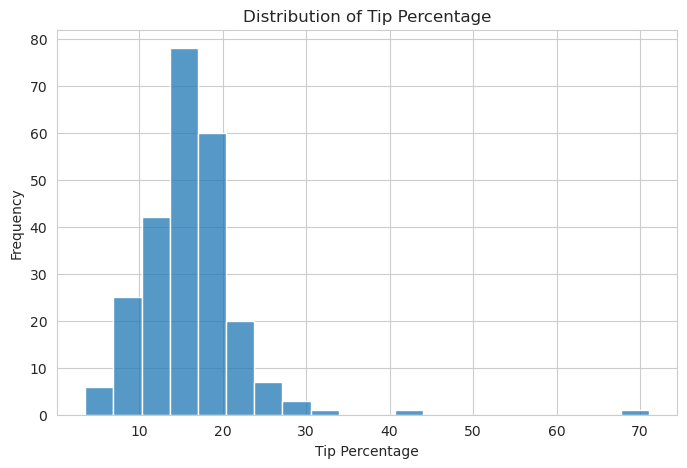

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(df["tip_percentage"], bins=20)

plt.title("Distribution of Tip Percentage")
plt.xlabel("Tip Percentage")
plt.ylabel("Frequency")

plt.show()

In [7]:
df["tip_percentage"].mean()

16.08025817225047

The average tip percentage is approximately **16.08%**, indicating that customers typically tip around the commonly expected range in restaurants.

The distribution shows that most tips fall between **12% and 20%**, with a concentration around **15–17%**. A few higher outliers appear, which may occur in cases of small bills or exceptional service experiences.

## Distribution of Total Bills

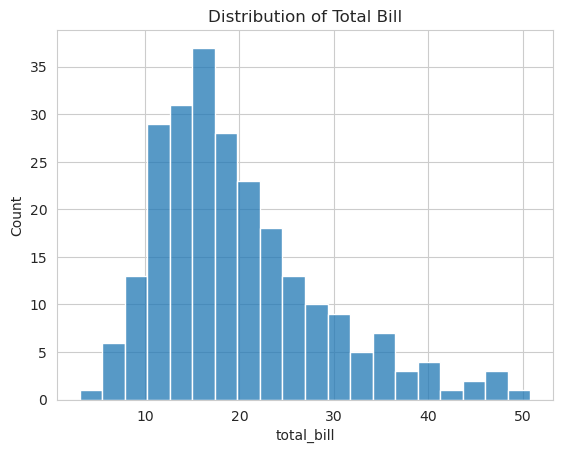

In [8]:
sns.histplot(df["total_bill"], bins=20)
plt.title("Distribution of Total Bill")
plt.show()

## Tip vs Total Bill

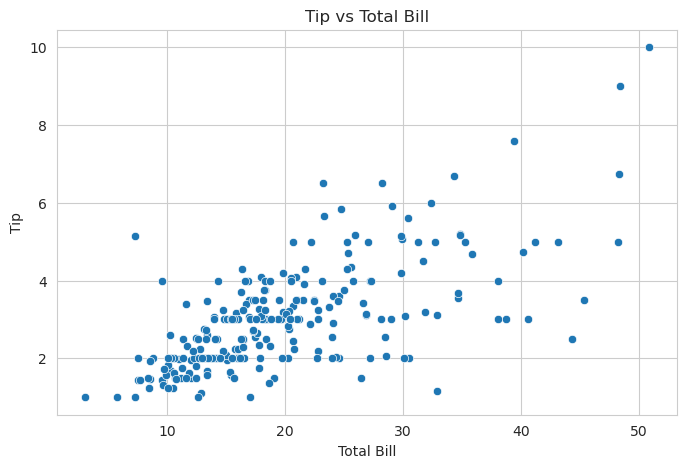

In [9]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x="total_bill", y="tip", data=df)
plt.title("Tip vs Total Bill")
plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.savefig("../images/tip_vs_total_bill.png", dpi=300, bbox_inches="tight")
plt.show()

## Correlation Analysis

We analyze correlations between numerical variables to understand how strongly they relate to each other.

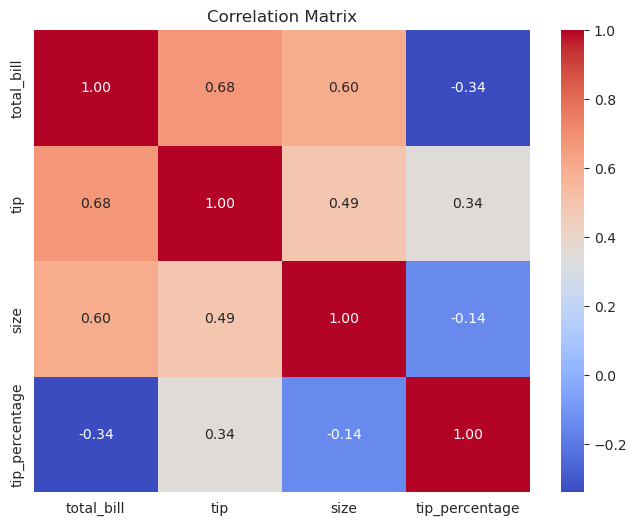

In [10]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Matrix")
plt.show()

The correlation matrix shows a strong positive relationship between **total bill and tip (0.68)**, indicating that larger bills typically result in higher tips.

There is also a notable correlation between **table size and total bill (0.60)**, suggesting that larger groups tend to generate higher spending.

Interestingly, **tip percentage shows a slight negative correlation with total bill (-0.34)**, which may indicate that while larger bills receive higher tips in absolute terms, the relative tip percentage tends to decrease slightly.

## Spending by Meal Time

This analysis compares customer spending behavior between lunch and dinner transactions.

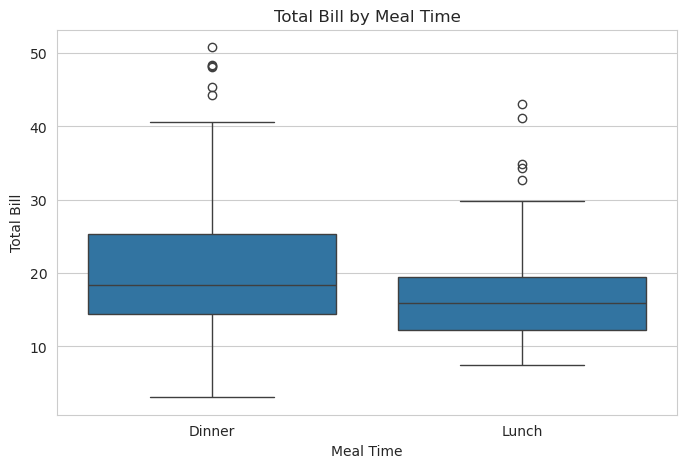

In [11]:
plt.figure(figsize=(8,5))

sns.boxplot(x="time", y="total_bill", data=df)

plt.title("Total Bill by Meal Time")
plt.xlabel("Meal Time")
plt.ylabel("Total Bill")

plt.show()

Dinner transactions tend to generate higher total bills compared to lunch.

The median spending during dinner is noticeably higher, and the variability is also greater, suggesting that dinner customers often place larger or more diverse orders.

Lunch transactions appear more consistent and generally involve smaller bills.

## Tipping Behavior: Smokers vs Non-Smokers

This analysis explores whether smoking status influences tipping behavior.

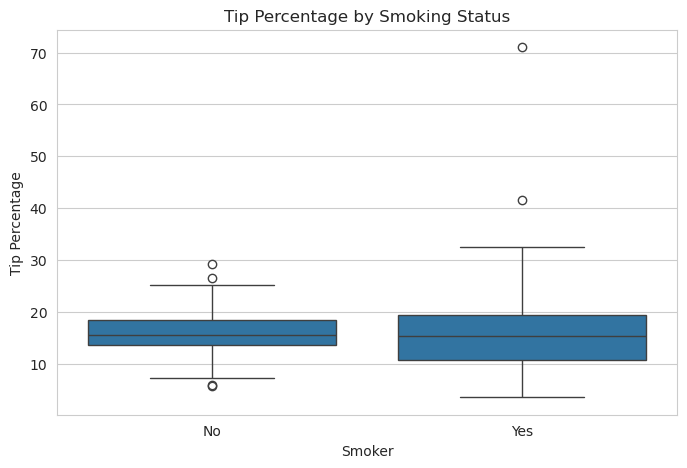

In [12]:
plt.figure(figsize=(8,5))

sns.boxplot(x="smoker", y="tip_percentage", data=df)

plt.title("Tip Percentage by Smoking Status")
plt.xlabel("Smoker")
plt.ylabel("Tip Percentage")

plt.show()

There is no clear difference in tipping behavior between smokers and non-smokers.

Both groups show similar median tip percentages, suggesting that smoking status does not significantly influence tipping behavior.

A few high outliers appear among smokers, but these likely represent exceptional cases rather than a consistent pattern.

## Bills by Day

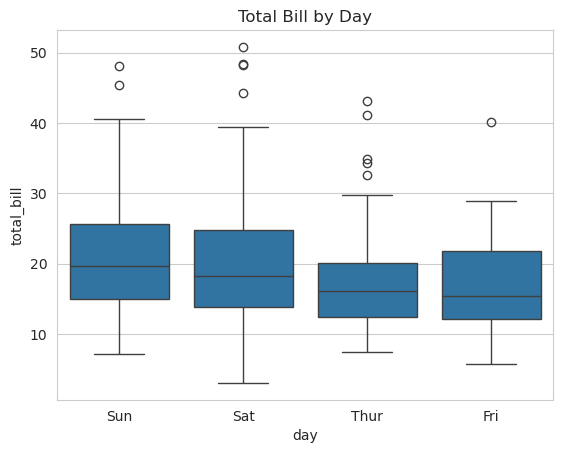

In [13]:
sns.boxplot(x="day", y="total_bill", data=df)
plt.title("Total Bill by Day")
plt.show()

## Key Insights

• Larger restaurant bills tend to generate higher tips, showing a strong positive relationship between **total bill** and **tip amount**.

• Dinner transactions generally produce higher bills than lunch, indicating stronger customer spending during dinner service.

• Larger groups tend to generate higher total bills, as shown by the positive correlation between **table size** and **total bill**.

• Tip percentages mostly fall between **12% and 20%**, with an average of approximately **16.08%**.

• Smoking status does not appear to significantly influence tipping behavior, as smokers and non-smokers show similar median tip percentages.

## Conclusion

This exploratory data analysis shows that restaurant spending patterns are influenced by meal time, group size, and total bill amount.

Dinner transactions tend to generate higher bills, larger tables contribute to higher spending, and tipping behavior remains relatively consistent, with most customers tipping around **16%**.

Overall, the analysis provides useful business insights that could help restaurant managers better understand customer behavior and revenue drivers.